<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_77_imbalanced_data_yt/Lecture_77_imbalanced_data_yt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# importing the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

In [5]:
# set random seed for reproducibility
np.random.seed(42)


In [6]:
# Generate imbalanced dataset
n_samples_1 = 25
n_samples_2 = 375
center = [(0,0), (2,2)]
cluster_std = [1.5,1.5]

In [7]:
X, y = make_blobs(n_samples=[n_samples_1, n_samples_2], centers=center, cluster_std=cluster_std, random_state=0)



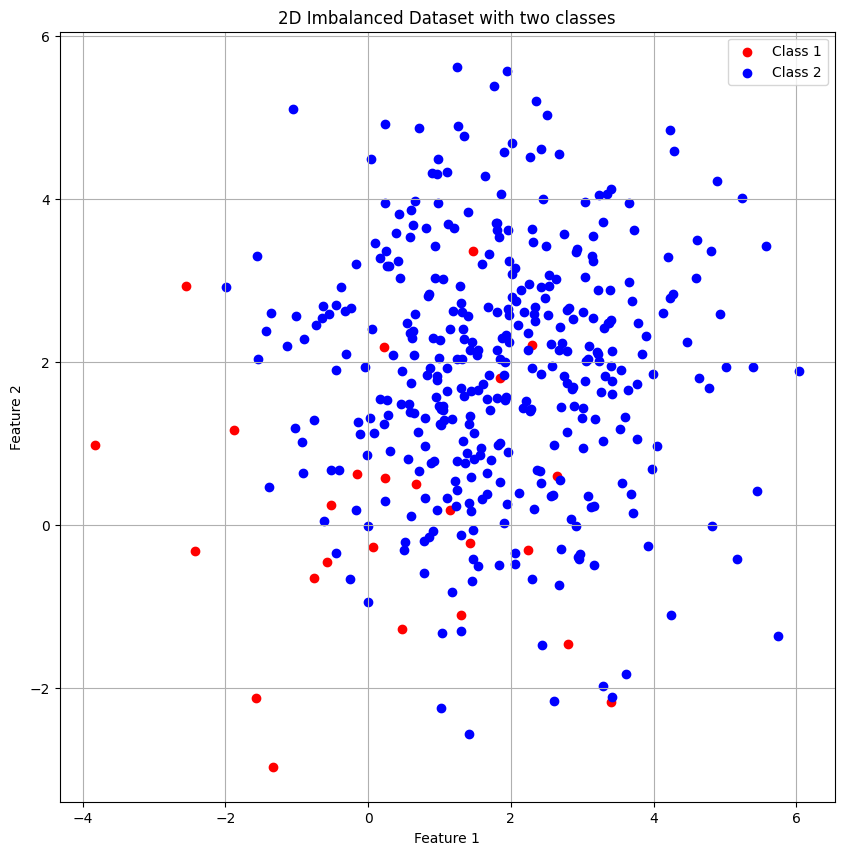

In [8]:
# plotting
plt.figure(figsize=(10,10))
plt.scatter(X[y == 0][:, 0],X[y == 0][:,1], color='red', label='Class 1')
plt.scatter(X[y == 1][:, 0],X[y == 1][:,1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with two classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

In [10]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
# Initialize and train RandomForest classifier
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

LogisticRegression()

In [12]:
# predict test set
y_pred = classifier.predict(X_test)
y_proba = classifier.predict_proba(X_test)[:, 1]

In [13]:
# Print classification report
print('Classification Report:')
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.29      0.44         7
           1       0.96      1.00      0.98       113

    accuracy                           0.96       120
   macro avg       0.98      0.64      0.71       120
weighted avg       0.96      0.96      0.95       120



In [14]:
# print ROC AUC Score
print('ROC AUC Score:', roc_auc_score(y_test, y_proba))

ROC AUC Score: 0.9557522123893806


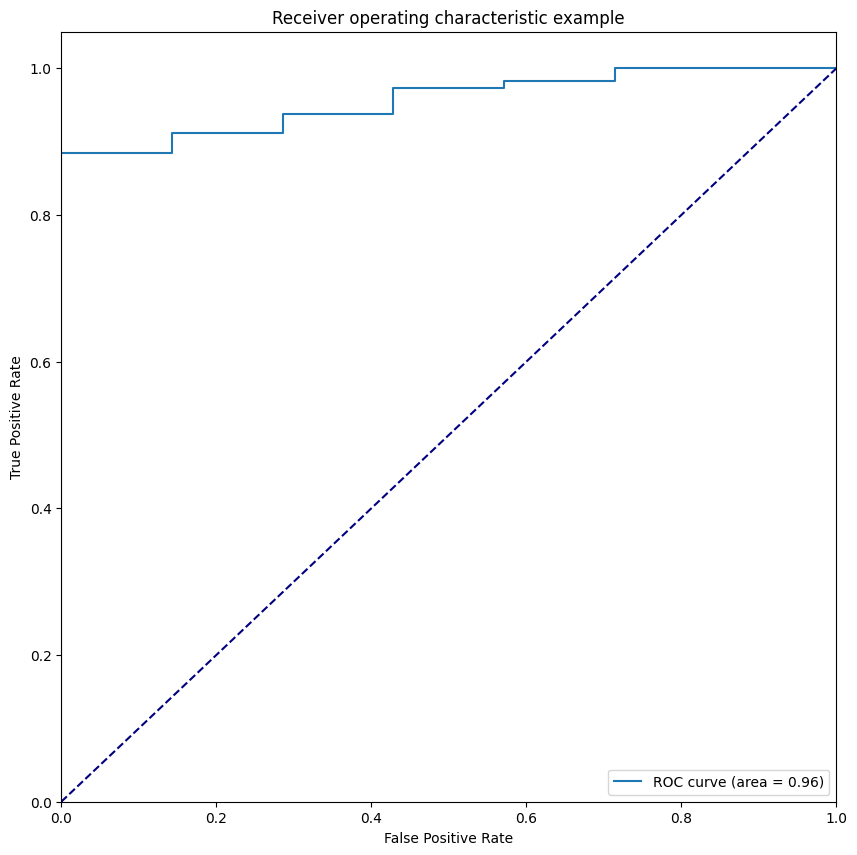

In [15]:
# plotting ROC AUC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(10,10))
plt.plot(fpr, tpr, label= 'ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_proba))
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic example')
plt.legend(loc="lower right")
plt.show()

In [16]:
# Function to plot decision boundaries
def plot_decision_boundary(X, y, model):
  plot_step = 0.02
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))
  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)
  plt.contourf(xx, yy, Z, alpha=0.3)
  plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s =20)
  plt.title('Decision Boundary')
  plt.show()


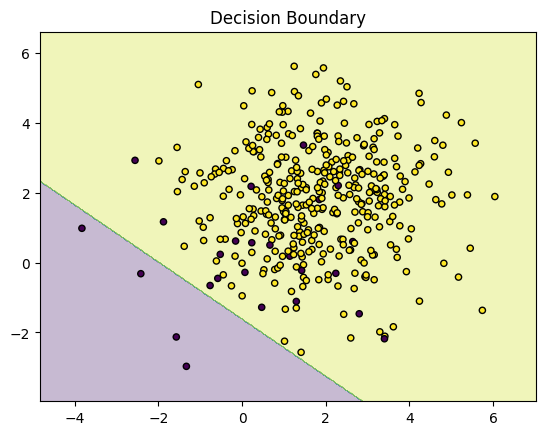

In [17]:
# plot decision boundary
plot_decision_boundary(X, y, classifier)

# Random Undersampling

In [18]:
from imblearn.under_sampling import RandomUnderSampler

In [19]:
# split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Applying Random Over Sampling
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

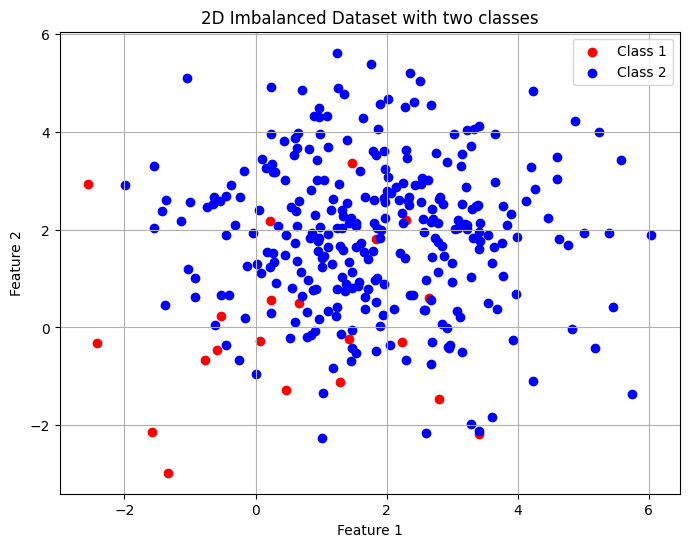

In [21]:
# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0][:, 0], X_train[y_train == 0][:, 1],color='red', label='Class 1')
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], color='blue', label='Class 2')
plt.title('2D Imbalanced Dataset with two classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()